# Disordered XXZ TEBD: Qualitative MBL Signatures

This notebook uses TEBD on a disordered spin-1/2 XXZ chain to show two standard dynamical signatures associated with many-body localization:

- persistent imbalance from a N'eel initial state at strong disorder
- slower entanglement growth than in a weak-disorder run on the same chain

The comparison is qualitative rather than a phase-diagram calculation. The goal is to show how to build a long-time TEBD workflow for a disordered Hamiltonian where moderate bond dimension can still be useful on the localized side.


In [1]:
using Random
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit

default(size=(920, 620), linewidth=2, markersize=4, legend=:best)


## Model and workflow

The Hamiltonian is

```math
H = \sum_{j=1}^{L-1} \left[J (S^x_j S^x_{j+1} + S^y_j S^y_{j+1}) + \Delta S^z_j S^z_{j+1}\right] + \sum_{j=1}^L h_j S^z_j
```

with open boundaries and random fields `h_j in [-W, W]`.

The notebook compares two disorder strengths built from the same base disorder realization:

- `W = 1.0`: weak disorder, used here as a more thermalizing reference
- `W = 8.0`: strong disorder, used here as the localized case

Important parameters in the TEBD call:

- `dt`: full odd-even-odd Strang time step
- `tmax`: total evolution time
- `sample_every`: number of TEBD sweeps between measurements
- `maxdim`: maximum kept bond dimension during gate application
- `cutoff`: discarded-weight threshold during compression
- `entropy_bond`: bond where `bond_entropy(psi, entropy_bond)` is measured


In [2]:
function disordered_xxz_bond_hamiltonian(nsites, bond, fields; Jxy::Real=1.0, Delta::Real=1.0)
    spins = spinhalf_matrices()
    two_site =
        Jxy * kron(spins.Sx, spins.Sx) +
        Jxy * kron(spins.Sy, spins.Sy) +
        Delta * kron(spins.Sz, spins.Sz)

    left_weight = bond == 1 ? 1.0 : 0.5
    right_weight = bond == (nsites - 1) ? 1.0 : 0.5
    field_term =
        left_weight * fields[bond] * kron(spins.Sz, spins.I) +
        right_weight * fields[bond + 1] * kron(spins.I, spins.Sz)

    return ComplexF64.(two_site + field_term)
end

function neel_state(sites)
    return MPS(sites, site -> isodd(site) ? "Up" : "Dn")
end

function imbalance(sz_values)
    nsites = length(sz_values)
    return (2 / nsites) * sum(((-1)^(site - 1)) * sz_values[site] for site in 1:nsites)
end

function run_disordered_xxz_tebd(fields; Jxy::Real=1.0, Delta::Real=1.0, dt::Real, tmax::Real, sample_every::Integer, maxdim::Integer, cutoff::Real, entropy_bond::Integer)
    nsites = length(fields)
    sites = siteinds("S=1/2", nsites)
    psi = neel_state(sites)
    # `local_hamiltonian(bond, weight)` returns the dense bond term for one schedule entry.
    # `weight` is the Strang-splitting coefficient supplied by `tebd_strang_evolution(...)`.
    evolution = tebd_strang_evolution(
        nsites,
        dt;
        local_hamiltonian=(bond, weight) -> weight * disordered_xxz_bond_hamiltonian(nsites, bond, fields; Jxy=Jxy, Delta=Delta),
        maxdim=maxdim,
        cutoff=cutoff,
    )

    nsteps = round(Int, tmax / dt)
    measure_steps = collect(0:sample_every:nsteps)
    times = dt .* measure_steps
    imbalances = Float64[]
    entropies = Float64[]
    maxlinkdims = Int[]
    final_profile = zeros(Float64, nsites)

    for step in 0:nsteps
        if step in measure_steps
            sz_values = expect(psi, "Sz")
            push!(imbalances, imbalance(sz_values))
            push!(entropies, bond_entropy(psi, entropy_bond))
            push!(maxlinkdims, maxlinkdim(psi))
            final_profile .= sz_values
        end
        step == nsteps && break
        evolve!(psi, evolution)
    end

    return (; times, imbalances, entropies, maxlinkdims, final_profile, fields)
end


run_disordered_xxz_tebd (generic function with 1 method)

## Parameters

These defaults are chosen to keep the notebook in a regime where the MBL-like run stays tractable at longer times with moderate bond dimension:

- `nsites = 20`: larger than the earlier benchmark notebook, but still practical for an example
- `dt = 0.1`: moderate TEBD time step for qualitative dynamics
- `tmax = 30.0`: long enough to separate weak and strong disorder qualitatively
- `maxdim = 64`: intentionally modest, so the strong-disorder case benefits from slower entanglement growth
- `cutoff = 1e-9`: compression threshold during TEBD
- `sample_every = 2`: measure every two Strang sweeps
- `entropy_bond = nsites ÷ 2`: mid-chain entanglement cut


In [3]:
Random.seed!(7)

nsites = 20
dt = 0.1
tmax = 30.0
sample_every = 2
maxdim = 64
cutoff = 1e-9
entropy_bond = nsites ÷ 2
Jxy = 1.0
Delta = 1.0

base_fields = 2 .* rand(Random.default_rng(), nsites) .- 1
weak_fields = 1.0 .* base_fields
strong_fields = 8.0 .* base_fields

weak_run = run_disordered_xxz_tebd(
    weak_fields;
    Jxy=Jxy,
    Delta=Delta,
    dt=dt,
    tmax=tmax,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    entropy_bond=entropy_bond,
)

strong_run = run_disordered_xxz_tebd(
    strong_fields;
    Jxy=Jxy,
    Delta=Delta,
    dt=dt,
    tmax=tmax,
    sample_every=sample_every,
    maxdim=maxdim,
    cutoff=cutoff,
    entropy_bond=entropy_bond,
)

println("weak-disorder final imbalance = ", weak_run.imbalances[end])
println("strong-disorder final imbalance = ", strong_run.imbalances[end])
println("weak-disorder final entropy = ", weak_run.entropies[end])
println("strong-disorder final entropy = ", strong_run.entropies[end])
println("weak-disorder max bond dimension = ", maximum(weak_run.maxlinkdims))
println("strong-disorder max bond dimension = ", maximum(strong_run.maxlinkdims))


weak-disorder final imbalance = 0.1165175698209374
strong-disorder final imbalance = 0.6568086356044984
weak-disorder final entropy = 3.307573081132952
strong-disorder final entropy = 0.10608318366730529
weak-disorder max bond dimension = 64
strong-disorder max bond dimension = 15


## Time traces

The two most useful diagnostics here are:

- **imbalance** `I(t)`: starts at `1` for the N'eel state; weak disorder should relax more strongly, while strong disorder should retain memory
- **mid-chain entropy**: grows more slowly on the strong-disorder run, which is why longer-time TEBD stays workable at moderate `chi`


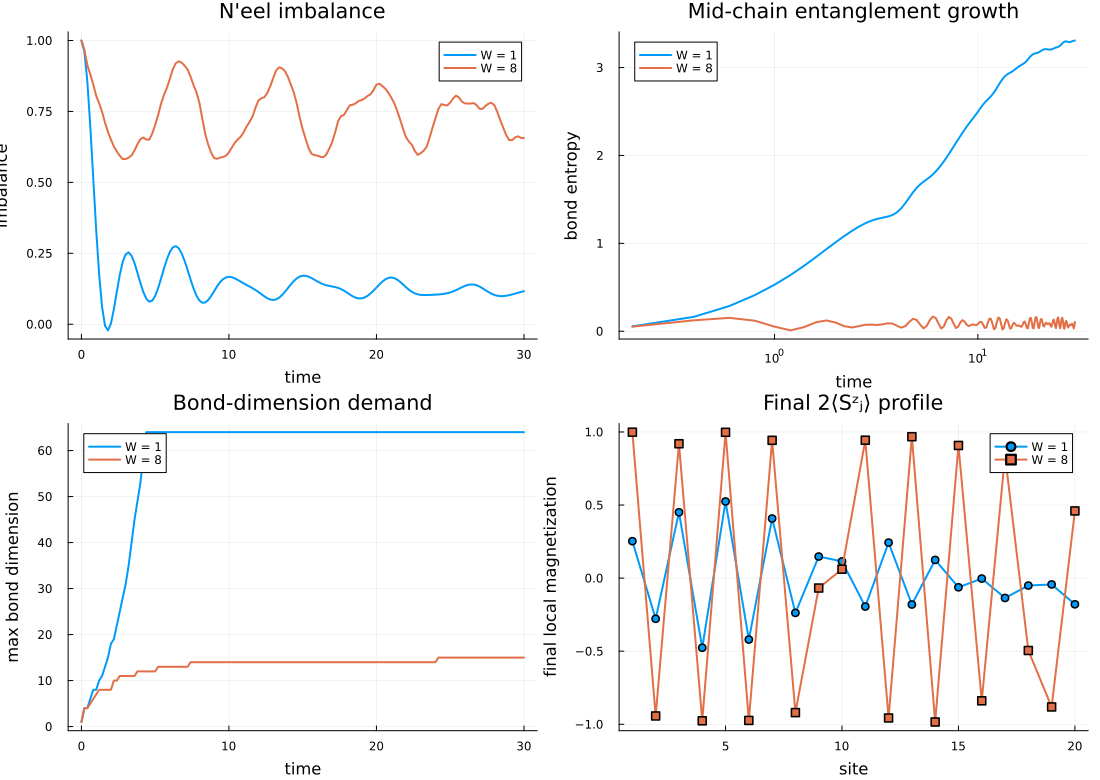

In [4]:
time_plots = plot(layout=(2, 2), size=(1100, 780))

plot!(
    time_plots[1],
    weak_run.times,
    weak_run.imbalances;
    label="W = 1",
    xlabel="time",
    ylabel="imbalance",
    title="N'eel imbalance",
)
plot!(
    time_plots[1],
    strong_run.times,
    strong_run.imbalances;
    label="W = 8",
)

plot!(
    time_plots[2],
    weak_run.times[2:end],
    weak_run.entropies[2:end];
    label="W = 1",
    xlabel="time",
    ylabel="bond entropy",
    xscale=:log10,
    title="Mid-chain entanglement growth",
)
plot!(
    time_plots[2],
    strong_run.times[2:end],
    strong_run.entropies[2:end];
    label="W = 8",
)

plot!(
    time_plots[3],
    weak_run.times,
    weak_run.maxlinkdims;
    label="W = 1",
    xlabel="time",
    ylabel="max bond dimension",
    title="Bond-dimension demand",
)
plot!(
    time_plots[3],
    strong_run.times,
    strong_run.maxlinkdims;
    label="W = 8",
)

plot!(
    time_plots[4],
    1:nsites,
    2 .* weak_run.final_profile;
    marker=:circle,
    label="W = 1",
    xlabel="site",
    ylabel="final local magnetization",
    title="Final 2⟨Sᶻⱼ⟩ profile",
)
plot!(
    time_plots[4],
    1:nsites,
    2 .* strong_run.final_profile;
    marker=:square,
    label="W = 8",
)

display(time_plots)


## Reading the result

What to look for in this example:

- If the strong-disorder run keeps a noticeably larger imbalance at late time, the chain retains local memory of the N'eel pattern.
- If the strong-disorder entropy grows more slowly, TEBD can reach later times before `maxdim` becomes the main bottleneck.
- If the weak-disorder run pushes the bond dimension harder and washes out the final staggered profile, that is the expected contrast with the more localized run.

This notebook is meant as a workflow example, not a sharp MBL transition study. For more serious finite-size analysis you would average over many disorder realizations, vary `L`, and check the stability of the qualitative separation with respect to `dt`, `cutoff`, and `maxdim`.
